In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
home = Path.home()
data_path = home / 'Programming/data/fraud-detection' / 'data'
data_df = pd.read_csv(data_path / 'transactions_obf.csv',
                      parse_dates=['transactionTime'],
                      dtype={'availableCash': np.float64,
                             'transactionAmount': np.float64})
data_df.sort_values(by='transactionTime', inplace=True)

In [3]:
data_df[['eventId', 'accountNumber', 'merchantId', 'mcc', 'merchantCountry', 'merchantZip', 'posEntryMode']] = data_df[['eventId', 'accountNumber', 'merchantId', 'mcc', 'merchantCountry', 'merchantZip', 'posEntryMode']].astype('string')

In [4]:
data_path = home / 'Programming/data/fraud-detection' / 'data'
labels_df = pd.read_csv(data_path / 'labels_obf.csv', parse_dates=['reportedTime'])
labels_df.sort_values(by='reportedTime', inplace=True)
data_df['fraudCase'] = data_df.eventId.isin(labels_df.eventId).astype(bool)

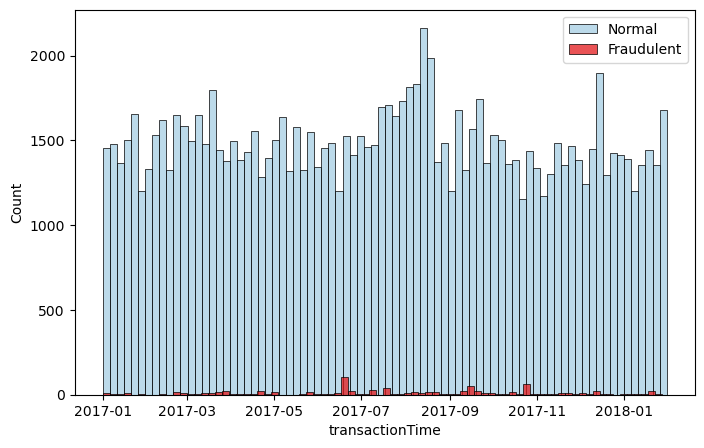

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
sns.histplot(data_df.transactionTime, bins=80,
             color='#A6CEE3', ax=ax, label='Normal')
transaction_df = data_df.transactionTime[data_df.fraudCase == 1]
sns.histplot(transaction_df, bins=80, color='#E31A1C',
             ax=ax, label='Fraudulent')
plt.legend();

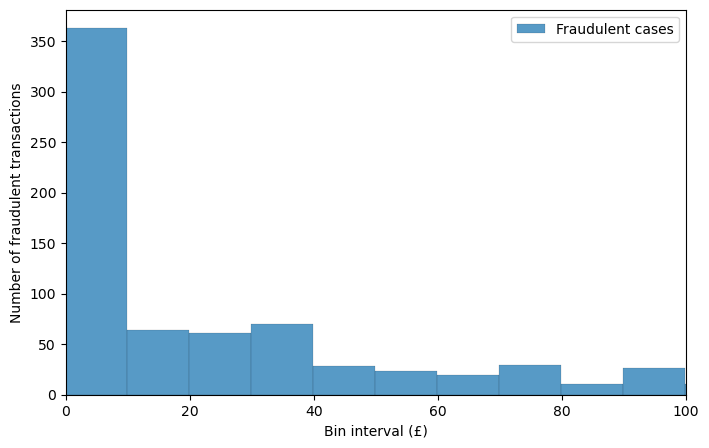

In [6]:
fig, ax = plt.subplots(figsize=(8,5))
amount_df = data_df.transactionAmount[data_df.fraudCase == 1]
sns.histplot(amount_df, bins=500, color='#1F78B4', ax=ax, label='Fraudulent cases')
ax.set_xlim([0, 100])
ax.set_xlabel('Bin interval (£)')
ax.set_ylabel('Number of fraudulent transactions')
plt.legend();

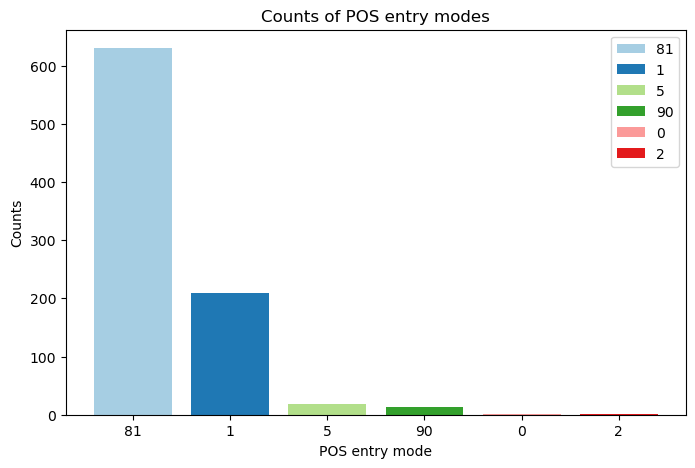

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
fraud_df = data_df[data_df.fraudCase == 1]
pos_fraud_df = fraud_df.posEntryMode.value_counts(ascending=False)
ax.bar(pos_fraud_df.index, pos_fraud_df.values, label=pos_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('POS entry mode')
ax.set_ylabel('Counts')
ax.set_title('Counts of POS entry modes')
plt.legend();

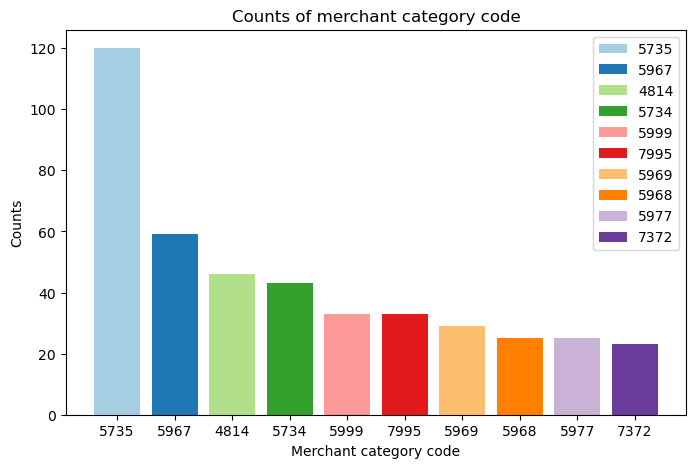

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
mcc_fraud_df = fraud_df.mcc.value_counts(ascending=False)[:top_num]
ax.bar(mcc_fraud_df.index, mcc_fraud_df.values, label=mcc_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant category code')
ax.set_ylabel('Counts')
ax.set_title('Counts of merchant category code')
plt.legend();

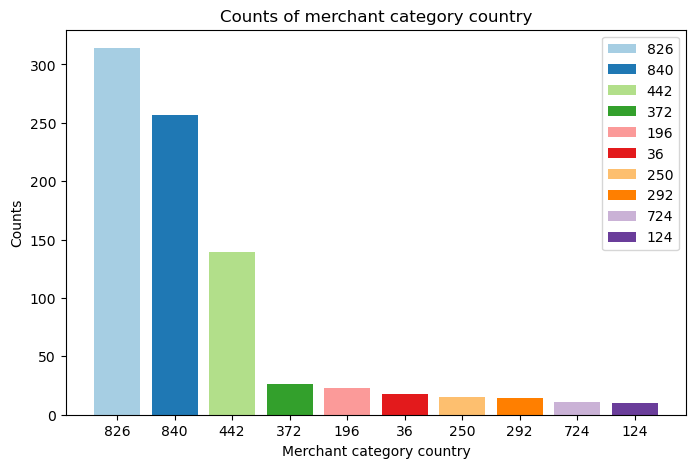

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
mctry_fraud_df = fraud_df.merchantCountry.value_counts(ascending=False)[:top_num]
ax.bar(mctry_fraud_df.index, mctry_fraud_df.values, label=mctry_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant category country')
ax.set_ylabel('Counts')
ax.set_title('Counts of merchant category country')
plt.legend();

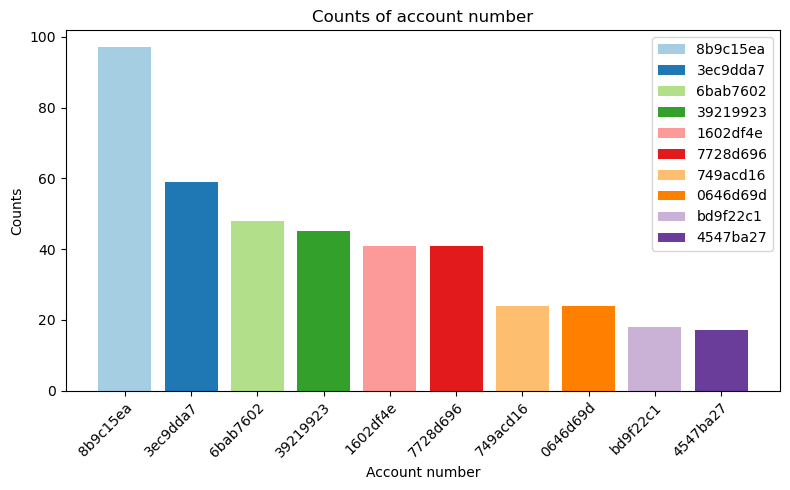

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
an_fraud_df = fraud_df.accountNumber.value_counts(ascending=False)[:top_num]
ax.bar(an_fraud_df.index, an_fraud_df.values, label=an_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Account number')
ax.set_ylabel('Counts')
ax.set_title('Counts of account number')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.tight_layout()
plt.legend();

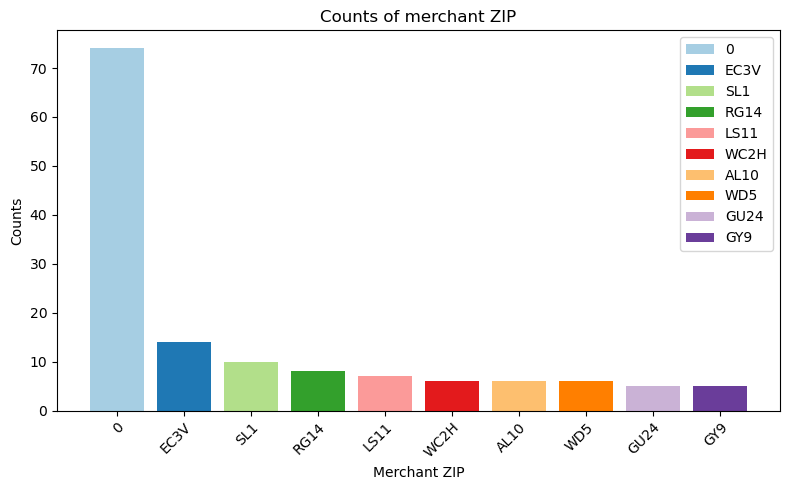

In [11]:
fig, ax = plt.subplots(figsize=(8,5))
top_num = 10
mz_fraud_df = fraud_df.merchantZip.value_counts(ascending=False)[:top_num]
ax.bar(mz_fraud_df.index, mz_fraud_df.values, label=mz_fraud_df.index,
       color=plt.cm.Paired.colors)
ax.set_xlabel('Merchant ZIP')
ax.set_ylabel('Counts')
ax.set_title('Counts of merchant ZIP')
plt.setp(ax.get_xticklabels(), ha='right',
         rotation_mode='anchor', rotation=45)
plt.tight_layout()
plt.legend();